<a href="https://colab.research.google.com/github/smonodeep/DynamicValuationGovernance/blob/main/0.Data_Prep_CityWise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data prep code

In [24]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import pandas_datareader.data as web
import datetime
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

In [25]:
rbi_hpi_path = '/content/House Price Index Publication_RBI.xlsx'

try:
    # Read only the specified range for the 2010-11 HPI block
    df_hpi_raw = pd.read_excel(rbi_hpi_path, sheet_name='House Price Index', header=None, skiprows=27, nrows=61, usecols='B:M')
    print(f"Successfully loaded RBI HPI Excel from {rbi_hpi_path}")
    # Display first few rows to verify loading
    print("Raw HPI data from specified range:")
    display(df_hpi_raw.head())
except FileNotFoundError:
    print(f"Error: RBI HPI Excel file not found at {rbi_hpi_path}")
    df_hpi_raw = pd.DataFrame()
except Exception as e:
    print(f"Error loading RBI HPI Excel: {e}")
    df_hpi_raw = pd.DataFrame()

Successfully loaded RBI HPI Excel from /content/House Price Index Publication_RBI.xlsx
Raw HPI data from specified range:


,1,2,3,4,5,6,7,8,9,10,11,12
0,NaN,Ahmedabad,Bangalore,Chennai*,Delhi,Jaipur,Kanpur,Kochi,Kolkata,Lucknow,Mumbai,All India
1,Q1.2010-11,93.218679,98.639697,102.731254,100.721966,95.312154,91.735054,89.611743,77.879138,88.82087,90.626706,94.239884
2,Q2.2010-11,102.54263,97.902562,109.501643,95.560697,99.047963,99.446163,92.376464,103.191573,98.671878,99.717032,99.811033
3,Q3.2010-11,101.99031,97.935658,94.647711,92.105168,103.574958,103.686822,113.849679,106.617769,104.745752,100.879902,99.404514
4,Q4.2010-11,102.248381,105.522082,93.119392,112.058101,102.064925,105.13196,104.162114,112.31152,107.761499,108.77636,106.63229


In [26]:
if not df_hpi_raw.empty:
    df_hpi = df_hpi_raw.copy()

    # The first row contains city names, the first column contains quarter labels
    city_names = df_hpi.iloc[0, 1:].tolist()
    # quarter_labels are in the first column, from the second row onwards
    # No need to extract quarter_labels explicitly here as they will be in the 'quarter' column after column setting

    # Set column names
    df_hpi.columns = ['quarter'] + city_names

    # Drop the first row (city names are now headers)
    df_hpi = df_hpi.drop(df_hpi.index[0])

    # Reset index
    df_hpi = df_hpi.reset_index(drop=True)

    # Convert wide format to long format
    df_hpi_long = df_hpi.melt(id_vars=['quarter'], var_name='city', value_name='hpi')

    # Ensure quarter and city are strings and hpi is numeric
    df_hpi_long['quarter'] = df_hpi_long['quarter'].astype(str)
    df_hpi_long['city'] = df_hpi_long['city'].astype(str)
    df_hpi_long['hpi'] = pd.to_numeric(df_hpi_long['hpi'], errors='coerce')

    print("HPI data after initial cleaning and melt:")
    display(df_hpi_long.head())
else:
    print("df_hpi_raw is empty, skipping HPI cleaning.")
    df_hpi_long = pd.DataFrame()

HPI data after initial cleaning and melt:


,quarter,city,hpi
0,Q1.2010-11,Ahmedabad,93.218679
1,Q2.2010-11,Ahmedabad,102.542630
2,Q3.2010-11,Ahmedabad,101.990310
3,Q4.2010-11,Ahmedabad,102.248381
4,Q1.2011-12,Ahmedabad,121.296551


In [27]:
if not df_hpi_long.empty:
    # 1. Lowercase city names, remove '*' and strip whitespace
    df_hpi_long['city'] = df_hpi_long['city'].str.lower().str.replace('*', '', regex=False).str.strip()

    # 2. Remove 'all india' and NaN HPI values
    df_hpi_long = df_hpi_long[df_hpi_long['city'] != 'all india']
    df_hpi_long = df_hpi_long.dropna(subset=['hpi'])

    # 3. Retain only specified cities
    common_cities = ['bangalore', 'chennai', 'delhi', 'mumbai']
    df_hpi_long = df_hpi_long[df_hpi_long['city'].isin(common_cities)].reset_index(drop=True)

    print("HPI data after standardization and city filtering:")
    print(f"Shape: {df_hpi_long.shape}")
    print(f"Unique cities: {df_hpi_long['city'].unique()}")
    display(df_hpi_long.head())
else:
    print("df_hpi_long is empty, skipping HPI standardization.")

HPI data after standardization and city filtering:
Shape: (240, 3)
Unique cities: ['bangalore' 'chennai' 'delhi' 'mumbai']


,quarter,city,hpi
0,Q1.2010-11,bangalore,98.639697
1,Q2.2010-11,bangalore,97.902562
2,Q3.2010-11,bangalore,97.935658
3,Q4.2010-11,bangalore,105.522082
4,Q1.2011-12,bangalore,110.679615


In [28]:
import re
import pandas as pd # Added this import

def parse_rbi_quarter(quarter_str):
    if pd.isna(quarter_str):
        return pd.NaT

    # Regex to capture Q number, 4-digit year, optional 2-digit year for financial year, and optional (P)** suffix
    # It's flexible with separator ('.' or space) and optional financial year part
    match = re.match(r'Q([1-4])[.\s](\d{4})(?:-(\d{2}))?(?:\(P\)\*\*)?', str(quarter_str))
    if match:
        q_num = int(match.group(1))
        start_year = int(match.group(2))
        # For financial year format like 2010-11, the first year is the start of the financial year.
        # Q1 (April-June) and Q2 (July-Sept) fall in the *first* calendar year of the financial year.
        # Q3 (Oct-Dec) and Q4 (Jan-Mar) fall in the *second* calendar year of the financial year.
        # For calendar year format (YYYY only), year is just start_year.

        # Default to start_year for calendar year and Q1/Q2 of financial year
        calendar_year = start_year

        if match.group(3): # This means it's a financial year format like 2010-11
            if q_num in [3, 4]: # Q3 (Oct-Dec) and Q4 (Jan-Mar) of financial year YYYY-YY fall in YYYY+1 calendar year
                calendar_year = start_year + 1

        return f"{calendar_year}Q{q_num}"
    return pd.NaT

# --- START of added code to define df_rent_agg ---
rental_data_path = '/content/Rental_Index_CREMatrix.csv'
df_rent_agg = pd.DataFrame() # Initialize to empty to prevent NameError if loading fails

try:
    df_rent_raw = pd.read_csv(rental_data_path)
    print(f"Successfully loaded Rental Index data from {rental_data_path}")

    df_rent = df_rent_raw.copy()

    # Rename columns for consistency and easier access
    df_rent.rename(columns={'City': 'city', 'Quarter': 'quarter', 'Rent': 'rent'}, inplace=True)

    # Standardize city names
    common_cities = ['bangalore', 'chennai', 'delhi', 'mumbai'] # Ensure this list is consistent with HPI data
    df_rent['city'] = df_rent['city'].str.lower().str.strip()

    # Map abbreviated city names to full names to match common_cities list
    city_name_mapping = {
        'blr': 'bangalore',
        'chn': 'chennai', # MODIFIED: Changed 'che' to 'chn'
        'del': 'delhi',
        'mum': 'mumbai',
        'bangalore': 'bangalore', # Ensure already correct names are also mapped to themselves
        'chennai': 'chennai',
        'delhi': 'delhi',
        'mumbai': 'mumbai'
    }
    df_rent['city'] = df_rent['city'].replace(city_name_mapping)

    df_rent = df_rent[df_rent['city'].isin(common_cities)].reset_index(drop=True)
    print("Cities in df_rent after mapping and filtering:", df_rent['city'].unique()) # Added print for diagnosis

    # Apply the improved parsing function for rent data
    df_rent['quarter_period'] = df_rent['quarter'].apply(parse_rbi_quarter)

    # Convert quarter_period to pandas Period objects
    df_rent['quarter_period'] = pd.PeriodIndex(df_rent['quarter_period'], freq='Q-DEC')

    # Drop rows where quarter_period could not be parsed or rent is missing
    df_rent.dropna(subset=['quarter_period', 'rent'], inplace=True)
    df_rent = df_rent.sort_values(by=['city', 'quarter_period']).reset_index(drop=True)

    # Aggregate rent data to have one rent value per city and quarter_period
    df_rent_agg = df_rent.groupby(['city', 'quarter_period'])['rent'].mean().reset_index() # MODIFIED: Aggregated rent

    print("\nRental data after cleaning and standardization (df_rent_agg created):")
    print(f"Shape: {df_rent_agg.shape}")
    print(f"Unique cities: {df_rent_agg['city'].nunique()}")
    print(f"Unique quarters: {df_rent_agg['quarter_period'].nunique()}")

except FileNotFoundError:
    print(f"Error: Rental Index CSV file not found at {rental_data_path}. df_rent_agg remains empty.")
except Exception as e:
    print(f"Error loading or processing Rental Index data for df_rent_agg: {e}")
    df_rent_agg = pd.DataFrame() # Ensure it's empty if an error occurs

# Initialize df_repo_quarterly to an empty DataFrame to prevent NameError later if it's not defined by another cell
df_repo_quarterly = pd.DataFrame()

# --- Fetch and Process FRED Repo Data ---
import pandas_datareader as pdr
import datetime

start_date_fixed = datetime.datetime(2010,1,1)
end_date_fixed = datetime.datetime(2025,1,1)

repo_rate_series_raw = pdr.get_data_fred('INDIRLTLT01STM',
                                       start=start_date_fixed,
                                       end=end_date_fixed)

# Ensure the column name is consistent
repo_rate_series_raw.columns = ['repo_rate']

# Convert the index (date) to quarter_period
repo_rate_series_raw['quarter_period'] = repo_rate_series_raw.index.to_period('Q-DEC')

# Aggregate by quarter_period, taking the mean of repo_rate for each quarter
df_repo_quarterly = repo_rate_series_raw.groupby('quarter_period')['repo_rate'].mean().reset_index()

# Ensure quarter_period is of PeriodIndex type (might lose type during reset_index without specific care)
df_repo_quarterly['quarter_period'] = pd.PeriodIndex(df_repo_quarterly['quarter_period'], freq='Q-DEC')

print("\nRepo rate data (df_repo_quarterly created):")
print(f"Shape: {df_repo_quarterly.shape}")
print(f"Unique quarters: {df_repo_quarterly['quarter_period'].nunique()}")
display(df_repo_quarterly.head())
# --- END of Fetch and Process FRED Repo Data ---


if not df_hpi_long.empty:
    # Apply the improved parsing function
    df_hpi_long['quarter_period'] = df_hpi_long['quarter'].apply(parse_rbi_quarter)

    # Convert quarter_period to pandas Period objects for proper merging and sorting
    # Ensure the frequency is quarterly (Q-DEC for end of December quarter)
    df_hpi_long['quarter_period'] = pd.PeriodIndex(df_hpi_long['quarter_period'], freq='Q-DEC')

    # Drop rows where quarter_period could not be parsed
    df_hpi_long.dropna(subset=['quarter_period'], inplace=True)

    # Ensure quarter_period is sorted for correct growth calculation later
    df_hpi_long = df_hpi_long.sort_values(by=['city', 'quarter_period']).reset_index(drop=True)

    print("HPI data after quarter period standardizationofed:")
    print(f"Shape: {df_hpi_long.shape}")
    print(f"Unique quarters: {df_hpi_long['quarter_period'].nunique()}")
    display(df_hpi_long.head())
else:
    print("df_hpi_long is empty, skipping quarter standardization.")

# Ensure df_rent_agg's quarter_period is also Period type (should already be from previous steps, but re-confirm)
# MODIFIED: Replaced deprecated pd.api.types.is_period_dtype
if not df_rent_agg.empty and not isinstance(df_rent_agg['quarter_period'].dtype, pd.PeriodDtype):
    df_rent_agg['quarter_period'] = pd.PeriodIndex(df_rent_agg['quarter_period'], freq='Q-DEC')
    print("\nConverted df_rent_agg['quarter_period'] to PeriodIndex.")

# Calculate HPI growth (Quarter-over-Quarter)
if not df_hpi_long.empty:
    df_hpi_long['hpi_growth'] = df_hpi_long.groupby('city')['hpi'].pct_change() * 100
    print("\nHPI data with growth calculation:")
    display(df_hpi_long.head())

# Merge HPI and Rent data
# First, align rent and HPI data to common cities and quarters
if not df_hpi_long.empty and not df_rent_agg.empty:
    df_panel = pd.merge(df_hpi_long.rename(columns={'hpi': 'hpi_value'}),
                        df_rent_agg,
                        on=['city', 'quarter_period'],
                        how='inner')
    print("\nPanel data after merging HPI and Rent:")
    print(f"Shape: {df_panel.shape}")
    display(df_panel.head())
else:
    print("HPI or Rent data is empty, skipping merge.")
    df_panel = pd.DataFrame()

# Merge with Repo Rate data
if not df_panel.empty and not df_repo_quarterly.empty:
    df_panel = pd.merge(df_panel,
                        df_repo_quarterly,
                        on='quarter_period',
                        how='left')

    # Diagnostic for repo rate merge
    merge_diagnostics_repo = df_panel[df_panel['repo_rate'].isna()]
    if not merge_diagnostics_repo.empty:
        print(f"\nWarning: {len(merge_diagnostics_repo)} rows have missing repo_rate after merge.")
        # Optionally display some of these rows
        # display(merge_diagnostics_repo.head())

    print("\nPanel data after merging Repo Rate:")
    print(f"Shape: {df_panel.shape}")
    display(df_panel.head())
else:
    print("Panel or Repo Rate data is empty, skipping merge.")

# Calculate valuation gap (assuming a simple ratio for now)
if not df_panel.empty:
    df_panel['valuation_gap'] = df_panel['hpi_value'] / df_panel['rent']
    print("\nPanel data with Valuation Gap:")
    display(df_panel.head())
else:
    print("df_panel is empty, skipping valuation gap calculation.")


# Final filtering and validation (simplified for now)
if not df_panel.empty:
    # Drop rows with any NaN in critical columns if they are not expected
    # For this exercise, let's keep all. Real-world might require dropping NaNs for HPI/Rent growth or valuation gap
    # df_final = df_panel.dropna(subset=['hpi_growth', 'rent_growth', 'valuation_gap'])

    df_final = df_panel.copy()
    df_final_model_dataset = df_panel.copy()

    print("\nFinal data for analysis:")
    print(f"Shape: {df_final.shape}")
    print("Columns:", df_final.columns.tolist())
    display(df_final.head())
else:
    print("df_panel is empty, final dataframes will be empty.")
    df_final = pd.DataFrame()
    df_final_model_dataset = pd.DataFrame()

Successfully loaded Rental Index data from /content/Rental_Index_CREMatrix.csv
Cities in df_rent after mapping and filtering: ['bangalore' 'chennai' 'delhi' 'mumbai']

Rental data after cleaning and standardization (df_rent_agg created):
Shape: (188, 3)
Unique cities: 4
Unique quarters: 47

Repo rate data (df_repo_quarterly created):
Shape: (54, 2)
Unique quarters: 54


,quarter_period,repo_rate
0,2011Q4,8.560000
1,2012Q1,8.267167
2,2012Q2,8.452167
3,2012Q3,8.155889
4,2012Q4,8.162513


HPI data after quarter period standardizationofed:
Shape: (240, 4)
Unique quarters: 60


,quarter,city,hpi,quarter_period
0,Q1.2010-11,bangalore,98.639697,2010Q1
1,Q2.2010-11,bangalore,97.902562,2010Q2
2,Q1.2011-12,bangalore,110.679615,2011Q1
3,Q2.2011-12,bangalore,107.833929,2011Q2
4,Q3.2010-11,bangalore,97.935658,2011Q3



HPI data with growth calculation:


...

,quarter,city,hpi_value,quarter_period,hpi_growth,rent,repo_rate
0,Q1.2014-15,bangalore,180.400000,2014Q1,27.099900,100.0000,8.804847
1,Q2.2014-15,bangalore,174.600000,2014Q2,-3.215078,108.2750,8.791340
2,Q3.2013-14,bangalore,169.256843,2014Q3,-3.060227,99.5375,8.569230
3,Q4.2013-14,bangalore,184.285621,2014Q4,8.879274,109.8875,8.181552
4,Q1.2015-16,bangalore,208.418714,2015Q1,13.095483,104.4500,7.782887



Panel data with Valuation Gap:


,quarter,city,hpi_value,quarter_period,hpi_growth,rent,repo_rate,valuation_gap
0,Q1.2014-15,bangalore,180.400000,2014Q1,27.099900,100.0000,8.804847,1.804000
1,Q2.2014-15,bangalore,174.600000,2014Q2,-3.215078,108.2750,8.791340,1.612561
2,Q3.2013-14,bangalore,169.256843,2014Q3,-3.060227,99.5375,8.569230,1.700433
3,Q4.2013-14,bangalore,184.285621,2014Q4,8.879274,109.8875,8.181552,1.677039
4,Q1.2015-16,bangalore,208.418714,2015Q1,13.095483,104.4500,7.782887,1.995392



Final data for analysis:
Shape: (180, 8)
Columns: ['quarter', 'city', 'hpi_value', 'quarter_period', 'hpi_growth', 'rent', 'repo_rate', 'valuation_gap']


,quarter,city,hpi_value,quarter_period,hpi_growth,rent,repo_rate,valuation_gap
0,Q1.2014-15,bangalore,180.400000,2014Q1,27.099900,100.0000,8.804847,1.804000
1,Q2.2014-15,bangalore,174.600000,2014Q2,-3.215078,108.2750,8.791340,1.612561
2,Q3.2013-14,bangalore,169.256843,2014Q3,-3.060227,99.5375,8.569230,1.700433
3,Q4.2013-14,bangalore,184.285621,2014Q4,8.879274,109.8875,8.181552,1.677039
4,Q1.2015-16,bangalore,208.418714,2015Q1,13.095483,104.4500,7.782887,1.995392


Summary Stats of the above dataset

In [29]:
if not df_final.empty:
    print("Summary Statistics for the Final Dataset:")
    display(df_final.describe(include='all'))
else:
    print("df_final is empty, cannot provide summary statistics.")

Summary Statistics for the Final Dataset:


,quarter,city,hpi_value,quarter_period,hpi_growth,rent,repo_rate,valuation_gap
count,180,180,180.000000,180,180.000000,180.000000,176.000000,180.000000
unique,45,4,NaN,45,NaN,NaN,NaN,NaN
top,Q1.2014-15,bangalore,NaN,2014Q1,NaN,NaN,NaN,NaN
freq,4,45,NaN,4,NaN,NaN,NaN,NaN
mean,NaN,NaN,270.958459,NaN,1.884594,127.553115,7.184771,2.160799
std,NaN,NaN,52.349286,NaN,7.481813,23.814589,0.687124,0.455177
min,NaN,NaN,166.502128,NaN,-15.906877,94.500000,5.910980,1.493861
25%,NaN,NaN,227.004840,NaN,-2.518057,109.430357,6.714939,1.794634
50%,NaN,NaN,274.524789,NaN,0.574642,121.650000,7.154993,1.966457
75%,NaN,NaN,314.865436,NaN,4.455993,140.700000,7.666958,2.521451


Create Visualizations

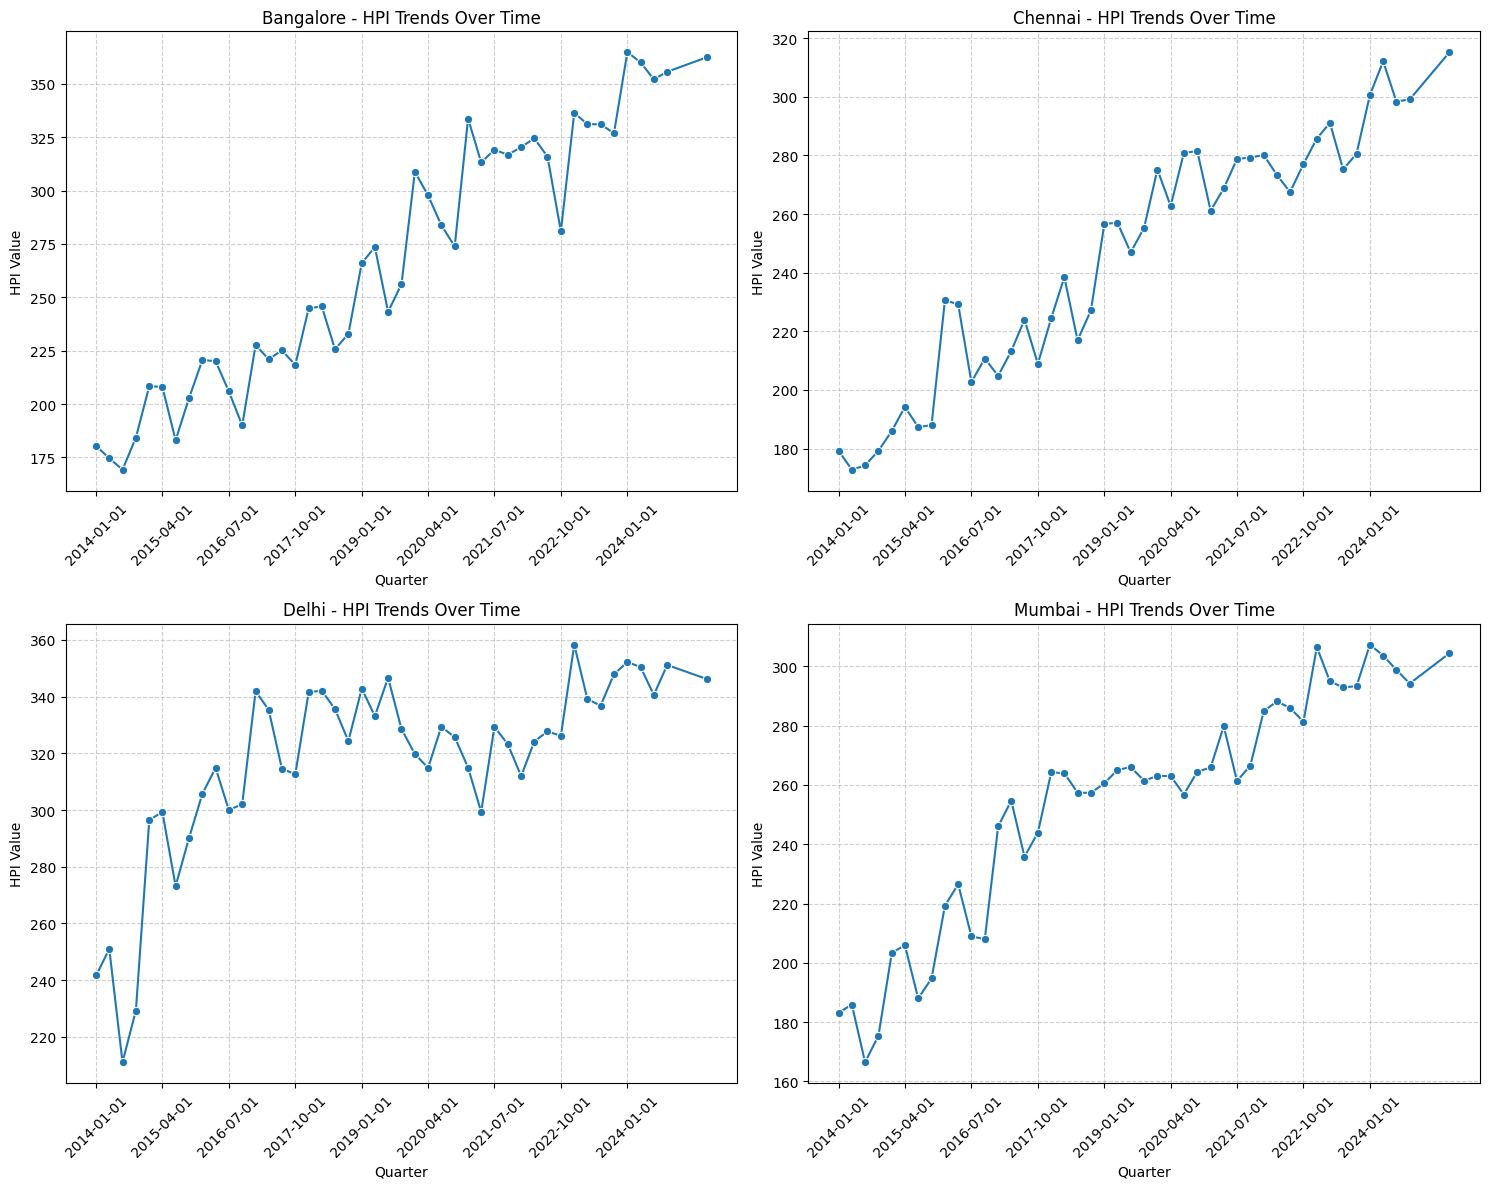

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported if not already globally available

if not df_final.empty:
    cities = df_final['city'].unique()
    n_cities = len(cities)

    # Determine the grid size for subplots
    # For 4 cities, a 2x2 grid is ideal
    n_rows = (n_cities + 1) // 2 if n_cities > 0 else 0 # 2 rows for 3 or 4 cities, 1 for 1 or 2
    n_cols = 2 if n_cities > 1 else 1

    if n_cities > 0:
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6 * n_rows), squeeze=False)
        axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

        for i, city in enumerate(cities):
            city_data = df_final[df_final['city'] == city].sort_values(by='quarter_period').copy()

            # Convert PeriodIndex to datetime for plotting compatibility
            city_data['quarter_plot'] = city_data['quarter_period'].dt.to_timestamp()

            sns.lineplot(x='quarter_plot', y='hpi_value', data=city_data, ax=axes[i], marker='o', hue='city', legend=False)
            axes[i].set_title(f'{city.capitalize()} - HPI Trends Over Time')
            axes[i].set_xlabel('Quarter')
            axes[i].set_ylabel('HPI Value')
            axes[i].tick_params(axis='x', rotation=45)
            axes[i].grid(True, linestyle='--', alpha=0.6)
            # Adjust x-axis ticks to show fewer labels if there are too many quarters
            if len(city_data['quarter_plot']) > 10:
                # Show every Nth tick for better readability
                n_ticks = len(city_data['quarter_plot'])
                tick_interval = max(1, n_ticks // 8) # Show about 8 ticks
                axes[i].set_xticks(city_data['quarter_plot'][::tick_interval])

        # Hide any unused subplots
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()
    else:
        print("No data in df_final to plot.")
else:
    print("df_final is empty, skipping HPI trend visualization.")

plot hpi growth

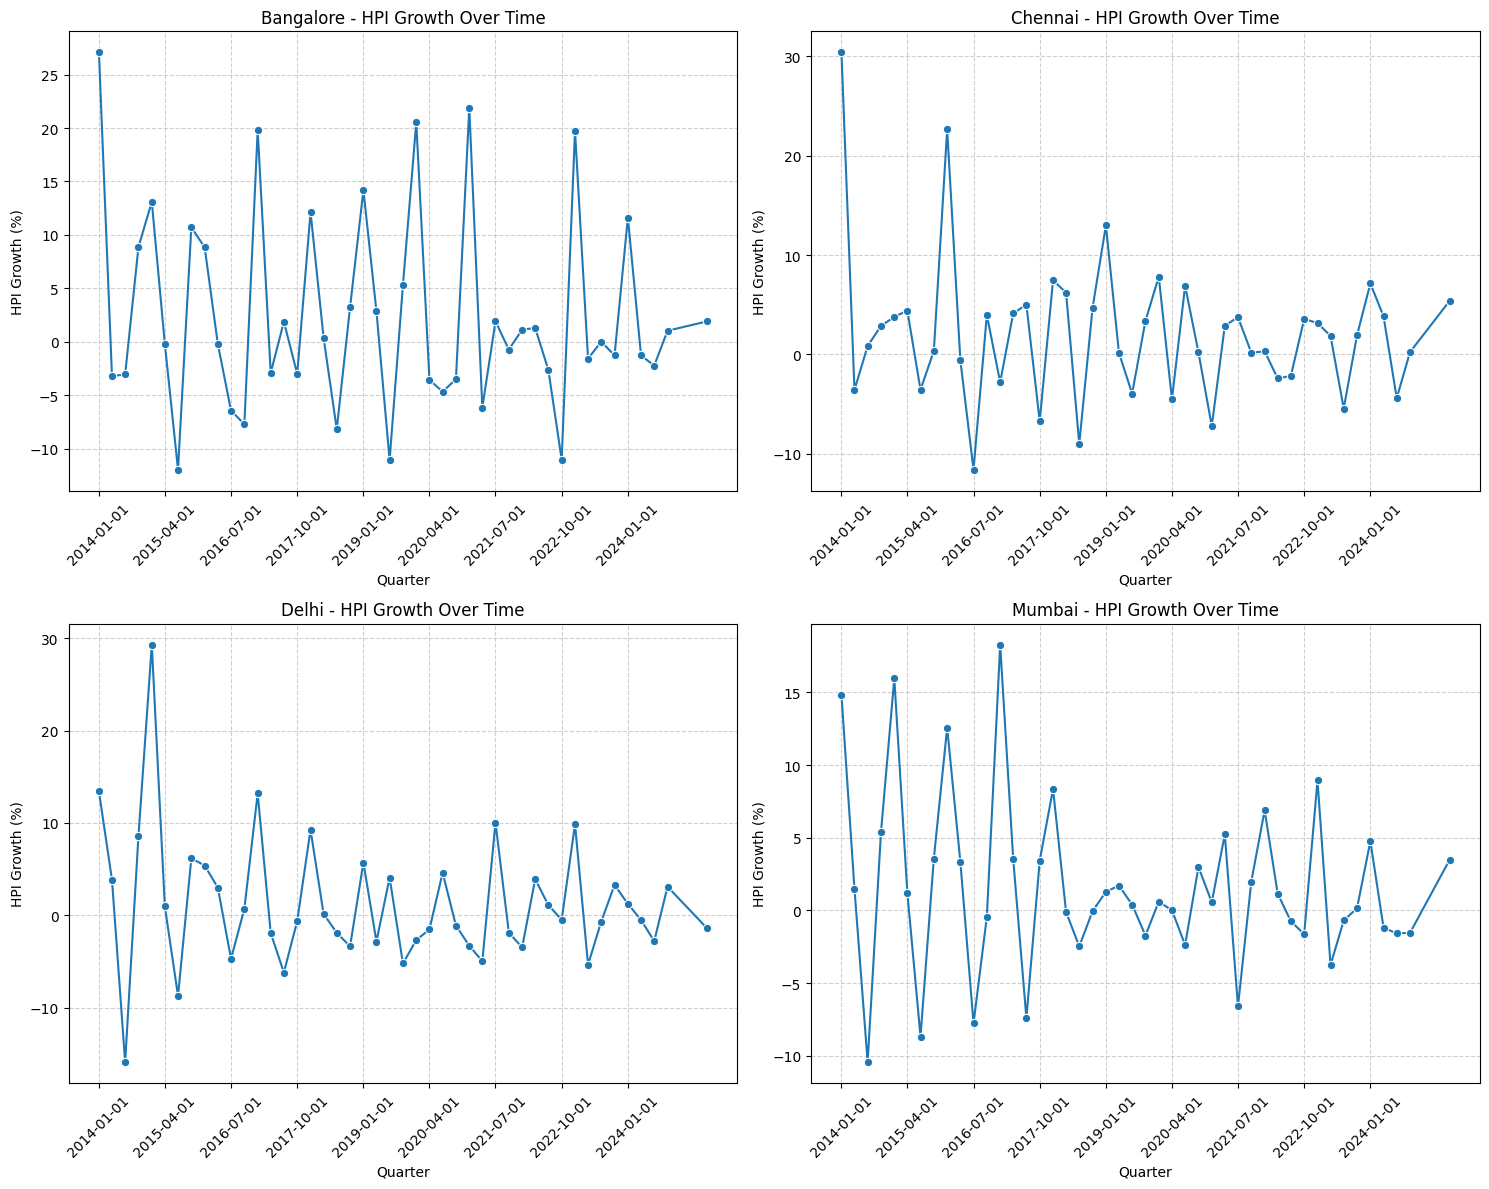

In [31]:
if not df_final.empty:
    cities = df_final['city'].unique()
    n_cities = len(cities)

    # Determine the grid size for subplots
    n_rows = (n_cities + 1) // 2 if n_cities > 0 else 0
    n_cols = 2 if n_cities > 1 else 1

    if n_cities > 0:
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6 * n_rows), squeeze=False)
        axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

        for i, city in enumerate(cities):
            city_data = df_final[df_final['city'] == city].sort_values(by='quarter_period').copy()

            # Convert PeriodIndex to datetime for plotting compatibility
            city_data['quarter_plot'] = city_data['quarter_period'].dt.to_timestamp()

            sns.lineplot(x='quarter_plot', y='hpi_growth', data=city_data, ax=axes[i], marker='o', hue='city', legend=False)
            axes[i].set_title(f'{city.capitalize()} - HPI Growth Over Time')
            axes[i].set_xlabel('Quarter')
            axes[i].set_ylabel('HPI Growth (%)')
            axes[i].tick_params(axis='x', rotation=45)
            axes[i].grid(True, linestyle='--', alpha=0.6)
            # Adjust x-axis ticks to show fewer labels if there are too many quarters
            if len(city_data['quarter_plot']) > 10:
                n_ticks = len(city_data['quarter_plot'])
                tick_interval = max(1, n_ticks // 8)
                axes[i].set_xticks(city_data['quarter_plot'][::tick_interval])

        # Hide any unused subplots
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()
    else:
        print("No data in df_final to plot HPI growth.")
else:
    print("df_final is empty, skipping HPI growth visualization.")

Whether Every City has Quarterly Contiguous Observation

In [32]:
for city in df_final_model_dataset['city'].unique():

    temp = (
        df_final_model_dataset[
            df_final_model_dataset['city'] == city
        ]
        .sort_values('quarter_period')
    )

    print(city)

    print(
        temp[
            ['quarter_period','hpi_value']
        ].head(15)
    )

bangalore
   quarter_period   hpi_value
0          2014Q1  180.400000
1          2014Q2  174.600000
2          2014Q3  169.256843
3          2014Q4  184.285621
4          2015Q1  208.418714
5          2015Q2  208.005441
6          2015Q3  183.081870
7          2015Q4  202.701601
8          2016Q1  220.607905
9          2016Q2  220.114393
10         2016Q3  205.923438
11         2016Q4  190.019080
12         2017Q1  227.657667
13         2017Q2  221.000240
14         2017Q3  225.138915
chennai
   quarter_period   hpi_value
45         2014Q1  179.200000
46         2014Q2  172.800000
47         2014Q3  174.276161
48         2014Q4  179.266495
49         2015Q1  186.043030
50         2015Q2  194.240046
51         2015Q3  187.336275
52         2015Q4  188.008501
53         2016Q1  230.574956
54         2016Q2  229.260379
55         2016Q3  202.686362
56         2016Q4  210.734586
57         2017Q1  204.832407
58         2017Q2  213.285635
59         2017Q3  223.966734
delhi
    quarter_peri

Visualize YOY growth for HPI

### Calculate Year-over-Year (YOY) HPI Growth

To understand the long-term trends and remove seasonal effects, we will calculate the Year-over-Year (YOY) growth rate for the HPI values. This is done by comparing the HPI value of the current quarter with the HPI value of the same quarter in the previous year. The formula used is:

$$ \text{YOY HPI Growth} = \left( \frac{\text{HPI}_t - \text{HPI}_{t-4}}{\text{HPI}_{t-4}} \right) \times 100 $$

Where $\text{HPI}_t$ is the HPI value for the current quarter and $\text{HPI}_{t-4}$ is the HPI value for the same quarter four periods (one year) ago.

In [33]:
if not df_final.empty:
    # Calculate Year-over-Year HPI growth
    df_final['hpi_yoy_growth'] = df_final.groupby('city')['hpi_value'].pct_change(periods=4) * 100
    print("\nFinal data with Year-over-Year HPI Growth:")
    display(df_final.head())
else:
    print("df_final is empty, skipping Year-over-Year HPI growth calculation.")


Final data with Year-over-Year HPI Growth:


,quarter,city,hpi_value,quarter_period,hpi_growth,rent,repo_rate,valuation_gap,hpi_yoy_growth
0,Q1.2014-15,bangalore,180.400000,2014Q1,27.099900,100.0000,8.804847,1.804000,NaN
1,Q2.2014-15,bangalore,174.600000,2014Q2,-3.215078,108.2750,8.791340,1.612561,NaN
2,Q3.2013-14,bangalore,169.256843,2014Q3,-3.060227,99.5375,8.569230,1.700433,NaN
3,Q4.2013-14,bangalore,184.285621,2014Q4,8.879274,109.8875,8.181552,1.677039,NaN
4,Q1.2015-16,bangalore,208.418714,2015Q1,13.095483,104.4500,7.782887,1.995392,15.531438


### Visualize Year-over-Year (YOY) HPI Growth

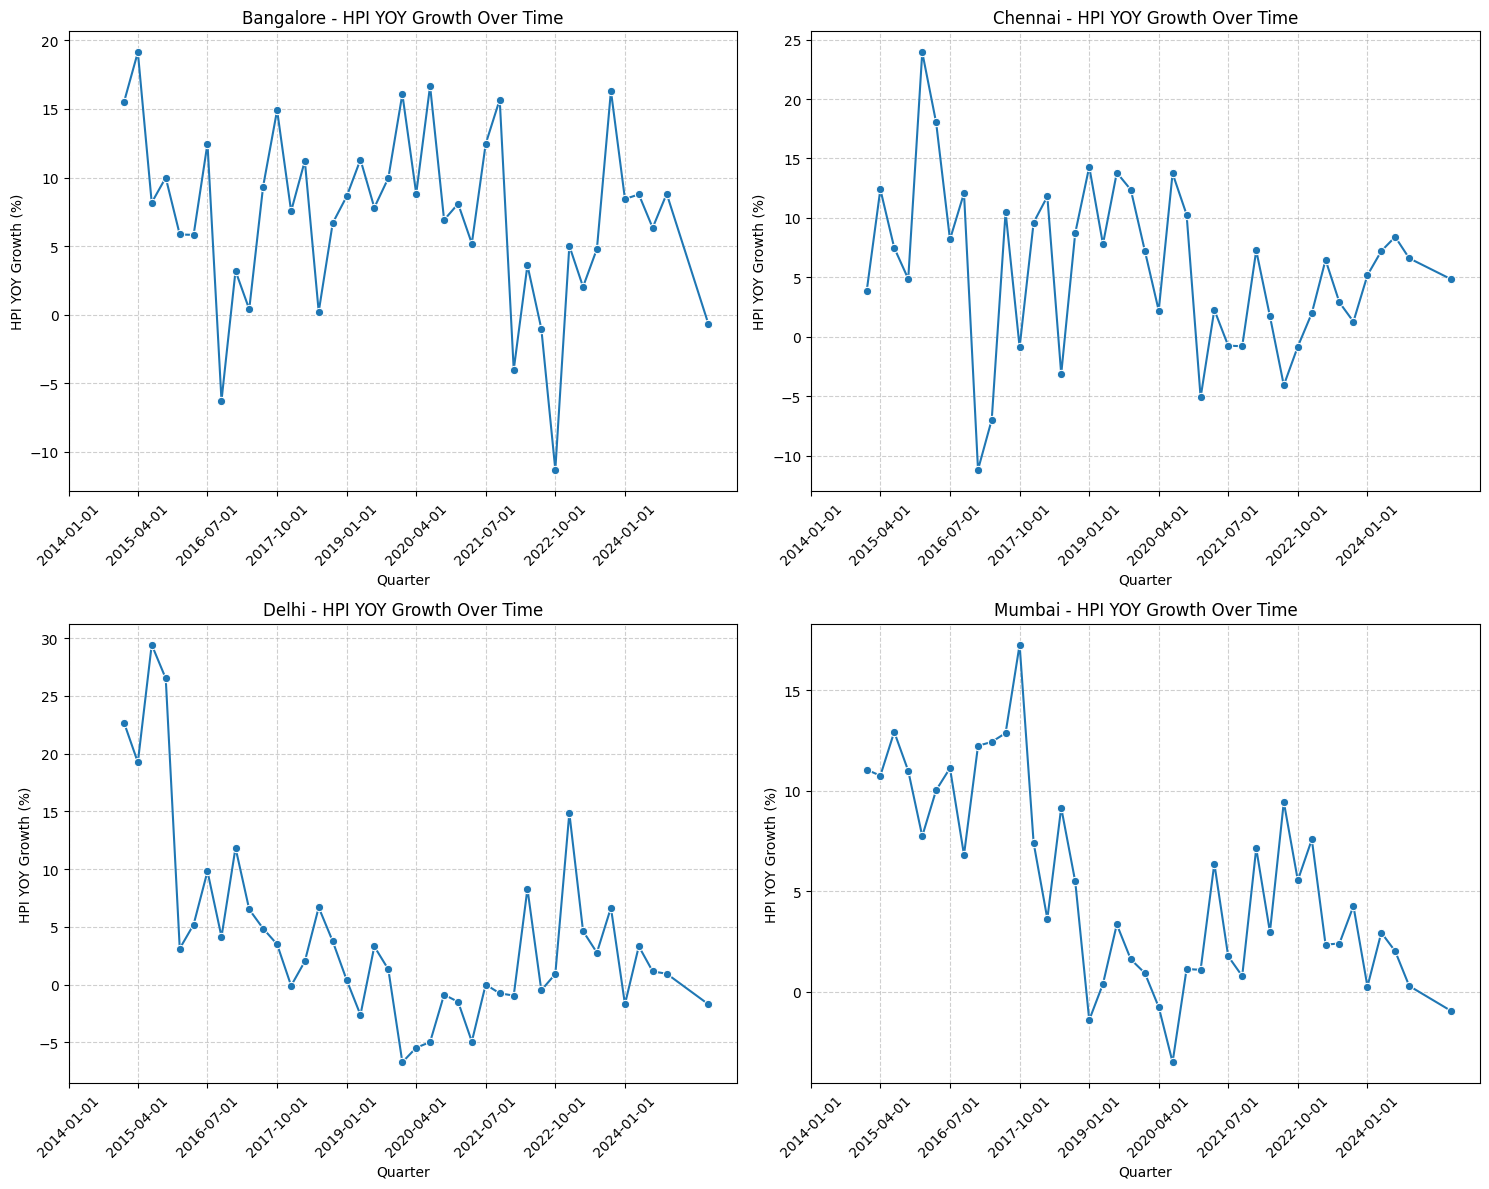

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

if not df_final.empty:
    cities = df_final['city'].unique()
    n_cities = len(cities)

    # Determine the grid size for subplots
    n_rows = (n_cities + 1) // 2 if n_cities > 0 else 0
    n_cols = 2 if n_cities > 1 else 1

    if n_cities > 0:
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6 * n_rows), squeeze=False)
        axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

        for i, city in enumerate(cities):
            city_data = df_final[df_final['city'] == city].sort_values(by='quarter_period').copy()

            # Convert PeriodIndex to datetime for plotting compatibility
            city_data['quarter_plot'] = city_data['quarter_period'].dt.to_timestamp()

            sns.lineplot(x='quarter_plot', y='hpi_yoy_growth', data=city_data, ax=axes[i], marker='o', hue='city', legend=False)
            axes[i].set_title(f'{city.capitalize()} - HPI YOY Growth Over Time')
            axes[i].set_xlabel('Quarter')
            axes[i].set_ylabel('HPI YOY Growth (%)')
            axes[i].tick_params(axis='x', rotation=45)
            axes[i].grid(True, linestyle='--', alpha=0.6)
            # Adjust x-axis ticks to show fewer labels if there are too many quarters
            if len(city_data['quarter_plot']) > 10:
                n_ticks = len(city_data['quarter_plot'])
                tick_interval = max(1, n_ticks // 8)
                axes[i].set_xticks(city_data['quarter_plot'][::tick_interval])

        # Hide any unused subplots
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()
    else:
        print("No data in df_final to plot HPI YOY growth.")
else:
    print("df_final is empty, skipping HPI YOY growth visualization.")

Calculate YoY for HPI, Rental and Repo, Final Dataset count, Summary Stats, Save in the content final dataset

In [35]:
import os

if not df_final.empty:
    # Calculate Year-over-Year (YOY) Rental Growth
    print("\nCalculating Year-over-Year Rental Growth...")
    df_final['rent_yoy_growth'] = df_final.groupby('city')['rent'].pct_change(periods=4) * 100
    print("Rental Year-over-Year Growth calculated.")

    # Repo Rate YoY Growth (Skipped if df_repo_quarterly is empty)
    if not df_repo_quarterly.empty and 'repo_rate' in df_final.columns:
        print("\nCalculating Year-over-Year Repo Rate Growth...")
        df_final['repo_yoy_growth'] = df_final.groupby('city')['repo_rate'].pct_change(periods=4) * 100
        print("Repo Rate Year-over-Year Growth calculated.")
    else:
        print("\nSkipping Repo Rate Year-over-Year growth calculation: `df_repo_quarterly` is empty or 'repo_rate' column not found in `df_final`.")

    print("\n--- Final Dataset Information ---")
    # Final Dataset Count
    print(f"Final Dataset Shape: {df_final.shape}")
    print(f"Number of rows: {df_final.shape[0]}")
    print(f"Number of columns: {df_final.shape[1]}")
    print("Columns in final dataset:", df_final.columns.tolist())

    # Summary Statistics
    print("\nSummary Statistics for the Final Dataset:")
    display(df_final.describe(include='all'))

    # Save the final dataset
    output_filename = 'final_analysis_dataset.csv'
    try:
        df_final.to_csv(output_filename, index=False)
        print(f"\nFinal dataset successfully saved to '{output_filename}'")
        print(f"File path: {os.path.abspath(output_filename)}")
    except Exception as e:
        print(f"\nError saving final dataset: {e}")

    print("\nUpdated head of df_final with new YoY columns:")
    display(df_final.head())

else:
    print("df_final is empty. Cannot perform requested operations.")



Calculating Year-over-Year Rental Growth...
Rental Year-over-Year Growth calculated.

Calculating Year-over-Year Repo Rate Growth...
Repo Rate Year-over-Year Growth calculated.

--- Final Dataset Information ---
Final Dataset Shape: (180, 11)
Number of rows: 180
Number of columns: 11
Columns in final dataset: ['quarter', 'city', 'hpi_value', 'quarter_period', 'hpi_growth', 'rent', 'repo_rate', 'valuation_gap', 'hpi_yoy_growth', 'rent_yoy_growth', 'repo_yoy_growth']

Summary Statistics for the Final Dataset:


/tmp/ipykernel_3444/1396755002.py:12: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_final['repo_yoy_growth'] = df_final.groupby('city')['repo_rate'].pct_change(periods=4) * 100


,quarter,city,hpi_value,quarter_period,hpi_growth,rent,repo_rate,valuation_gap,hpi_yoy_growth,rent_yoy_growth,repo_yoy_growth
count,180,180,180.000000,180,180.000000,180.000000,176.000000,180.000000,164.000000,164.000000,164.000000
unique,45,4,NaN,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Q1.2014-15,bangalore,NaN,2014Q1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,4,45,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,270.958459,NaN,1.884594,127.553115,7.184771,2.160799,5.669656,3.969717,-1.675760
std,NaN,NaN,52.349286,NaN,7.481813,23.814589,0.687124,0.455177,6.761650,7.049014,9.500924
min,NaN,NaN,166.502128,NaN,-15.906877,94.500000,5.910980,1.493861,-11.291872,-23.948465,-15.285240
25%,NaN,NaN,227.004840,NaN,-2.518057,109.430357,6.714939,1.794634,0.937614,-0.134544,-9.053560
50%,NaN,NaN,274.524789,NaN,0.574642,121.650000,7.154993,1.966457,5.192558,4.128472,-3.517426
75%,NaN,NaN,314.865436,NaN,4.455993,140.700000,7.666958,2.521451,9.663713,7.661736,7.230204



Final dataset successfully saved to 'final_analysis_dataset.csv'
File path: /content/final_analysis_dataset.csv

Updated head of df_final with new YoY columns:


,quarter,city,hpi_value,quarter_period,hpi_growth,rent,repo_rate,valuation_gap,hpi_yoy_growth,rent_yoy_growth,repo_yoy_growth
0,Q1.2014-15,bangalore,180.400000,2014Q1,27.099900,100.0000,8.804847,1.804000,NaN,NaN,NaN
1,Q2.2014-15,bangalore,174.600000,2014Q2,-3.215078,108.2750,8.791340,1.612561,NaN,NaN,NaN
2,Q3.2013-14,bangalore,169.256843,2014Q3,-3.060227,99.5375,8.569230,1.700433,NaN,NaN,NaN
3,Q4.2013-14,bangalore,184.285621,2014Q4,8.879274,109.8875,8.181552,1.677039,NaN,NaN,NaN
4,Q1.2015-16,bangalore,208.418714,2015Q1,13.095483,104.4500,7.782887,1.995392,15.531438,4.45,-11.606789


Plot City Wise Valuation_Gap
Rename df_final to final_model_dataset


--- Visualizing City-wise Valuation Gap ---


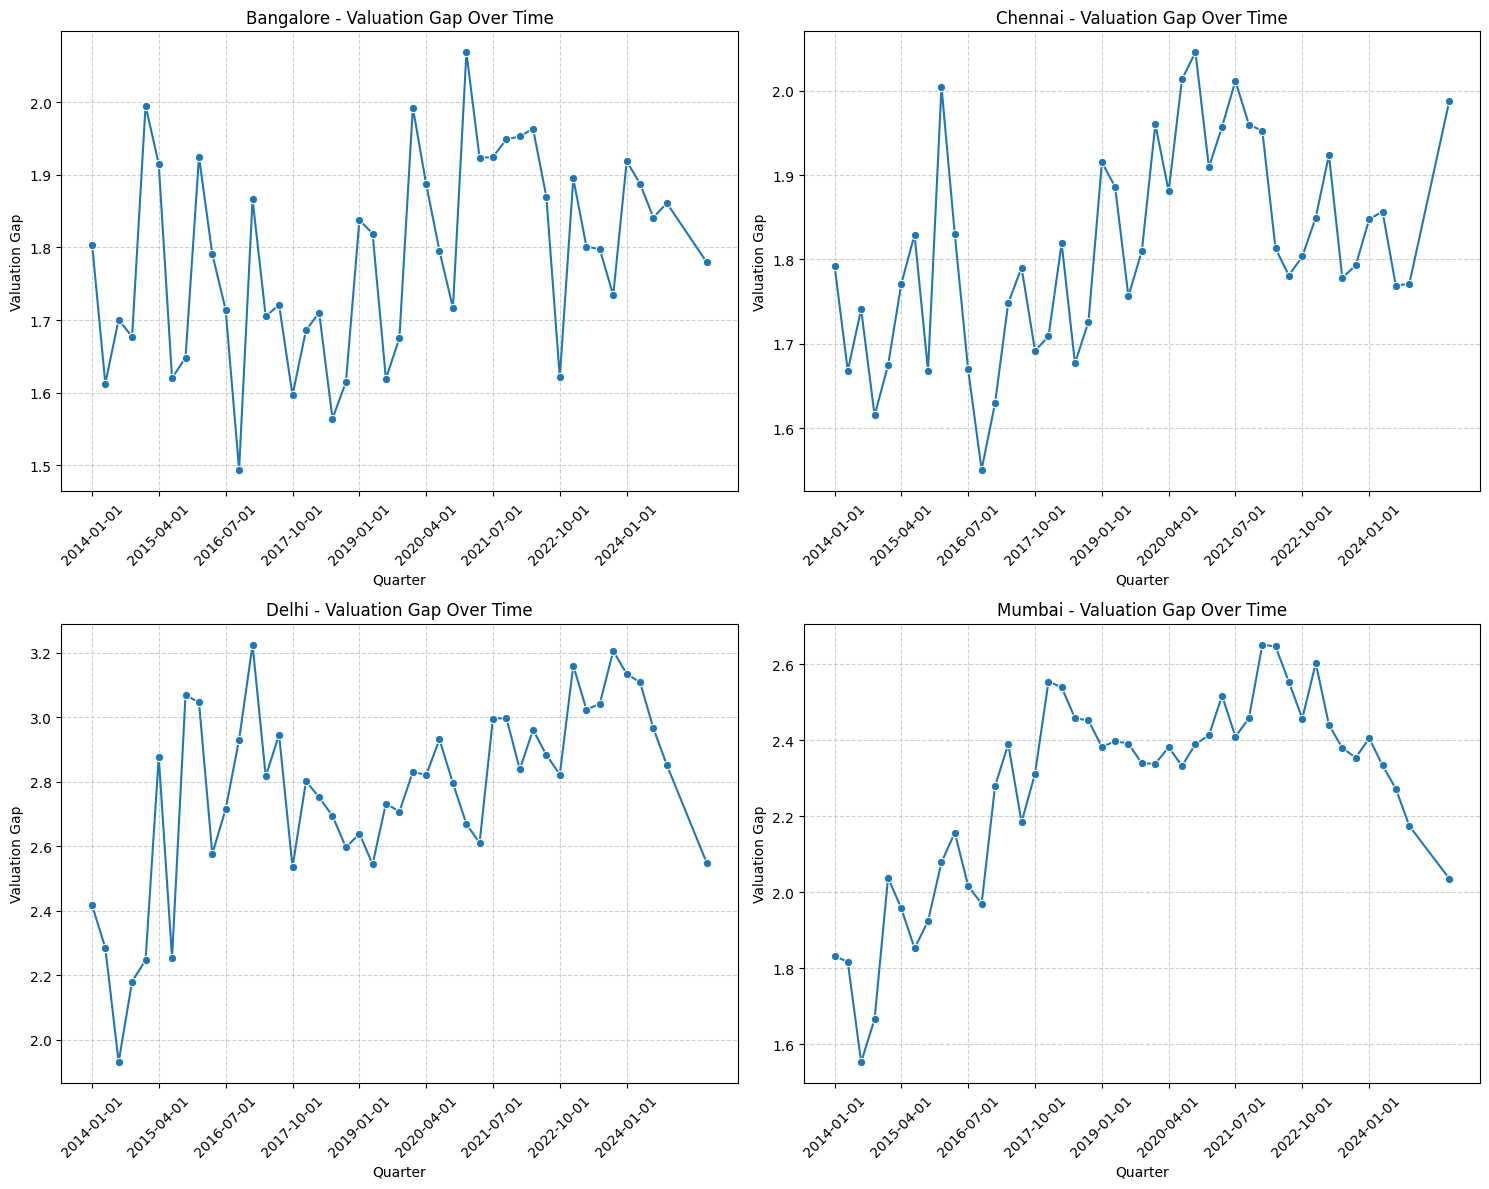


`df_final` has been copied to `final_model_dataset`.
`final_model_dataset` shape: (180, 11)
Head of `final_model_dataset`:


,quarter,city,hpi_value,quarter_period,hpi_growth,rent,repo_rate,valuation_gap,hpi_yoy_growth,rent_yoy_growth,repo_yoy_growth
0,Q1.2014-15,bangalore,180.400000,2014Q1,27.099900,100.0000,8.804847,1.804000,NaN,NaN,NaN
1,Q2.2014-15,bangalore,174.600000,2014Q2,-3.215078,108.2750,8.791340,1.612561,NaN,NaN,NaN
2,Q3.2013-14,bangalore,169.256843,2014Q3,-3.060227,99.5375,8.569230,1.700433,NaN,NaN,NaN
3,Q4.2013-14,bangalore,184.285621,2014Q4,8.879274,109.8875,8.181552,1.677039,NaN,NaN,NaN
4,Q1.2015-16,bangalore,208.418714,2015Q1,13.095483,104.4500,7.782887,1.995392,15.531438,4.45,-11.606789


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Plot City Wise Valuation_Gap ---
if not df_final.empty:
    print("\n--- Visualizing City-wise Valuation Gap ---")
    cities = df_final['city'].unique()
    n_cities = len(cities)

    n_rows = (n_cities + 1) // 2 if n_cities > 0 else 0
    n_cols = 2 if n_cities > 1 else 1

    if n_cities > 0:
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6 * n_rows), squeeze=False)
        axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

        for i, city in enumerate(cities):
            city_data = df_final[df_final['city'] == city].sort_values(by='quarter_period').copy()
            city_data['quarter_plot'] = city_data['quarter_period'].dt.to_timestamp()

            sns.lineplot(x='quarter_plot', y='valuation_gap', data=city_data, ax=axes[i], marker='o', hue='city', legend=False)
            axes[i].set_title(f'{city.capitalize()} - Valuation Gap Over Time')
            axes[i].set_xlabel('Quarter')
            axes[i].set_ylabel('Valuation Gap')
            axes[i].tick_params(axis='x', rotation=45)
            axes[i].grid(True, linestyle='--', alpha=0.6)
            # Adjust x-axis ticks to show fewer labels if there are too many quarters
            if len(city_data['quarter_plot']) > 10:
                n_ticks = len(city_data['quarter_plot'])
                tick_interval = max(1, n_ticks // 8)
                axes[i].set_xticks(city_data['quarter_plot'][::tick_interval])

        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()
    else:
        print("No data in df_final to plot Valuation Gap.")
else:
    print("df_final is empty, skipping Valuation Gap visualization.")

# --- Rename df_final to final_model_dataset ---
# The user wants to use final_model_dataset as the definitive dataset for modeling.
# Since df_final currently contains all the latest calculations (YOY growth for HPI and Rent),
# we should make final_model_dataset a copy of the current df_final.

if not df_final.empty:
    global final_model_dataset # Declare as global if modifying an existing global variable
    final_model_dataset = df_final.copy()
    print("\n`df_final` has been copied to `final_model_dataset`.")
    print(f"`final_model_dataset` shape: {final_model_dataset.shape}")
    print("Head of `final_model_dataset`:")
    display(final_model_dataset.head())
else:
    print("Cannot set `final_model_dataset` as `df_final` is empty.")


Calculate HPI lag,rent lag, repo lag, hpi growth, rent growth repo growth

In [37]:
import numpy as np
import pandas as pd # Ensure pandas is imported

# Ensure the dataset is sorted by city and quarter_period for correct group-wise operations
# This is crucial for accurate 'shift' and 'transform(lambda x: x.diff())' operations within groups.
final_model_dataset = final_model_dataset.sort_values(by=['city', 'quarter_period']).reset_index(drop=True)

# 1. Calculate Growth rates (log differences) - These must precede lag calculations

# HPI Growth: Calculate logarithmic difference.
# This will overwrite the 'hpi_growth' column which was previously calculated using pct_change
# if that column existed from prior steps. This cell's definition takes precedence.
final_model_dataset['hpi_growth'] = (
    final_model_dataset.groupby('city')['hpi_value']
        .transform(lambda x: np.log(x).diff())
)

# Rent Growth: Calculate logarithmic difference.
# This creates the 'rent_growth' column that was missing and caused the KeyError.
final_model_dataset['rent_growth'] = (
    final_model_dataset.groupby('city')['rent']
        .transform(lambda x: np.log(x).diff())
)

# Repo Growth: Calculate logarithmic difference.
# This relies on 'repo_rate'. Since df_repo_quarterly was empty, 'repo_rate' is likely not present.
# We'll check for its existence before attempting to calculate repo_growth.
if 'repo_rate' in final_model_dataset.columns:
    # Original repo_growth was a global shift, implying repo_rate is a national figure.
    # To correctly calculate a global shift on a DataFrame that is sorted by city, then quarter_period,
    # we need to create a temporary DataFrame sorted globally by quarter_period.
    temp_repo_df = final_model_dataset[['quarter_period', 'repo_rate']].drop_duplicates().sort_values('quarter_period').copy()
    temp_repo_df['repo_growth'] = (
        np.log(temp_repo_df['repo_rate']) - np.log(temp_repo_df['repo_rate'].shift(1))
    )
    # Merge global repo_growth back to the main dataframe
    final_model_dataset = pd.merge(
        final_model_dataset,
        temp_repo_df[['quarter_period', 'repo_growth']],
        on='quarter_period',
        how='left'
    )
else:
    print("Warning: 'repo_rate' column not found in final_model_dataset. Skipping 'repo_growth' calculation.")
    final_model_dataset['repo_growth'] = np.nan # Ensure the column exists, even if with NaNs


# 2. Calculate Lag features using the newly calculated growth rates

# HPI Lag
final_model_dataset['hpi_lag'] = (
    final_model_dataset
        .groupby('city')['hpi_growth']
        .shift(1)
)

# Rent Lag
final_model_dataset['rent_lag'] = (
    final_model_dataset
        .groupby('city')['rent_growth']
        .shift(1)
)

# Repo Lag
# This also depends on 'repo_growth' being calculated and will follow its global/local nature.
if 'repo_growth' in final_model_dataset.columns and not final_model_dataset['repo_growth'].isnull().all():
    # If repo_growth is global, its lag should also be global.
    # Replicate original logic of sorting by 'quarter_period' for shift.
    temp_repo_lag_df = final_model_dataset[['quarter_period', 'repo_growth']].drop_duplicates().sort_values('quarter_period').copy()
    temp_repo_lag_df['repo_lag'] = temp_repo_lag_df['repo_growth'].shift(1)

    # Merge the global repo_lag back. Drop existing repo_lag column if it was created as NaN earlier.
    final_model_dataset = final_model_dataset.drop(columns=['repo_lag'], errors='ignore')
    final_model_dataset = pd.merge(
        final_model_dataset,
        temp_repo_lag_df[['quarter_period', 'repo_lag']],
        on='quarter_period',
        how='left'
    )
else:
    print("Warning: 'repo_growth' not available or all NaNs, skipping 'repo_lag' calculation.")
    final_model_dataset['repo_lag'] = np.nan

In [38]:
import os

# Define the output filename for final_model_dataset
output_filename_model = 'final_model_dataset.csv'

if 'final_model_dataset' in locals() and not final_model_dataset.empty:
    try:
        final_model_dataset.to_csv(output_filename_model, index=False)
        print(f"Successfully saved `final_model_dataset` to '{output_filename_model}'")
        print(f"File path: {os.path.abspath(output_filename_model)}")
    except Exception as e:
        print(f"Error saving `final_model_dataset`: {e}")
else:
    print("`final_model_dataset` is not defined or is empty. Cannot save to CSV.")

Successfully saved `final_model_dataset` to 'final_model_dataset.csv'
File path: /content/final_model_dataset.csv
